# Learning 4 Robotics Expierments

In this lab you will train a robot to run by **watching an expert** — no hand-coded rules, no reward engineering. The technique is called **Behavior Cloning**:

1. An expert policy runs the robot; we record what it sees and does.
2. We treat those recordings as a supervised dataset: **input = observation, label = action**.
3. We train a small neural network (MLP) to predict the expert's actions.
4. We deploy our learned policy and compare it to the expert.

The robot is **HalfCheetah** from MuJoCo — a 2D simulated cheetah that learns to run forward.

---

## ⚙️ Setup — read this before running anything


### ☁️ Running on Google Colab

**1. Switch to a GPU runtime:**
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

**2. Run Step 0 first** and wait for `✅ Setup complete`.



## Step 0 — Colab Setup ☁️

> **Local users: skip this cell.**  
> **Colab users: run this cell first** and wait for `✅ Setup complete`.

In [3]:
# ════════════════════════════════════════════════
# COLAB ONLY — local users skip this cell
# ════════════════════════════════════════════════
import subprocess, sys, os

REPO = 'pgss-L4R-IL-public'
if not os.path.isdir(REPO):
    r = subprocess.run(['git', 'clone', 'https://github.com/alokshah04/pgss-L4R-IL-public.git'],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print('Repo already cloned.')
if not os.getcwd().endswith(REPO):
    os.chdir(REPO)
print('Working directory:', os.getcwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('\n✅ Setup complete. Continue to Step 1.')

Cloning into 'pgss-L4R-IL-public'...

Working directory: /content/pgss-L4R-IL-public

✅ Setup complete. Continue to Step 1.


In [ ]:
#import subprocess, sys, os
#this is jakes stuff
#print(subprocess.run(['git', 'clone', 'https://github.com/vwxyzjn/cleanrl.git'], capture_output=True, text=True).stdout)
#print(subprocess.run(['cd', 'cleanrl']).stdout)
#print(subprocess.run(['uv', 'pip', 'install', '.']).stdout)

---
## Step 1 — Imports and Expert 💻☁️

*(You may see a `Could not deserialize lr_schedule` warning — harmless. The policy weights load fine.)*

In [4]:
import gymnasium as gym
from stable_baselines3 import SAC
import imageio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Video, display

ENV_NAME    = 'HalfCheetah-v5'
EXPERT_PATH = 'experts/HalfCheetah-v5'

expert = SAC.load(EXPERT_PATH)
print('Expert policy loaded.')

env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}')   # what the robot sees
print(f'Action space:      {env.action_space}')        # what the robot does
env.close()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cl

Expert policy loaded.
Observation space: Box(-inf, inf, (17,), float64)
Action space:      Box(-1.0, 1.0, (6,), float32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Step 1a — Video recorder 💻 (local only)

> **Colab users: skip Steps 1a and 1b.** Video rendering requires a display, which Colab does not have.

We use gymnasium's built-in `rgb_array` renderer to record frames.

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def record_policy(step_fn, env_name, path, max_steps=300, seed=1, fps=30):
    """Run step_fn(obs) -> action and save an MP4 using gymnasium's rgb_array renderer."""
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, total_reward = [], 0.0
    for _ in range(max_steps):
        action = step_fn(obs)
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        frames.append(env.render())
        if done or truncated:
            break
    env.close()
    imageio.mimsave(path, frames, fps=fps)
    print(f'Saved {path}  |  reward: {total_reward:.1f}  |  frames: {len(frames)}')
    return total_reward

print('record_policy defined.')

### Step 1b — Watch the expert run 💻 (local only)

> **Colab users: skip this cell.**

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def expert_step(obs):
    action, _ = expert.predict(obs, deterministic=True)
    return action

record_policy(expert_step, ENV_NAME, 'expert_demo.mp4')
display(Video('expert_demo.mp4', embed=True, width=600))

---
## Step 2 — Collect Demonstrations 💻☁️

We roll out the expert many times and store every *(observation, action)* pair it produces.

Each **trajectory** is a dictionary with three lists:
```
{
  'obs'     : [o_0, o_1, ..., o_T],   # what the robot saw at each step
  'acts'    : [a_0, a_1, ..., a_T],   # what the expert did at each step
  'rewards' : [r_0, r_1, ..., r_T],   # reward received at each step
}
```

We collect `NUM_TRAJ` trajectories in total, then split them **70 / 10** into a **training set** and a **validation set**. The model only sees the training set during gradient updates; the validation set is used to check that it generalises to unseen data.

In [5]:
NUM_TRAJ      = 80
MAX_TIMESTEPS = 300
VAL_TRAJ      = 10   # held-out trajectories for validation

print(f'Collecting {NUM_TRAJ} expert trajectories...')

env = gym.make(ENV_NAME)
policy = SAC.load(EXPERT_PATH)
env.reset(seed=42)

all_trajectories = []
for ep in range(NUM_TRAJ):
    obs, _ = env.reset()
    traj = {'obs': [], 'acts': [], 'rewards': []}
    for _ in range(MAX_TIMESTEPS):
        traj['obs'].append(obs.copy())
        action, _ = policy.predict(obs, deterministic=True)
        traj['acts'].append(action)
        obs, reward, done, truncated, _ = env.step(action)
        traj['rewards'].append(reward)
        if done or truncated:
            break
    all_trajectories.append(traj)
env.close()

# Split into train and val
train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

print(f'Train trajectories: {len(train_trajs)}')
print(f'Val   trajectories: {len(val_trajs)}')

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cloudpickle.loads(base64_object)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Train trajectories: 70
Val   trajectories: 10


In [6]:
# Inspect one trajectory
traj0 = train_trajs[0]
obs0, acts0 = np.array(traj0['obs']), np.array(traj0['acts'])
print(f'Trajectory length: {len(traj0["obs"])} steps')
print(f'Observation shape: {obs0.shape}  (T x obs_dim)')
print(f'Action shape:      {acts0.shape}  (T x act_dim)')
print(f'Total reward:      {sum(traj0["rewards"]):.1f}')
print('\nFirst observation (what the robot sees at t=0):')
print(obs0[0])
print('\nFirst expert action (what the expert does at t=0):')
print(acts0[0])

Trajectory length: 300 steps
Observation shape: (300, 17)  (T x obs_dim)
Action shape:      (300, 6)  (T x act_dim)
Total reward:      2966.4

First observation (what the robot sees at t=0):
[ 0.02633288  0.05161755 -0.02909481  0.0941396   0.07862422  0.0556767
 -0.06107226 -0.0066558   0.03654441  0.04127326  0.0430821   0.21416476
 -0.0406415  -0.05122427 -0.08137727  0.06159794  0.11289723]

First expert action (what the expert does at t=0):
[ 0.9471673  -0.95543474  0.82663107 -0.9525958  -0.9551406  -0.9437293 ]


---
## Step 3 — Build a Supervised Learning Dataset 💻☁️

We flatten all trajectories into a flat list of *(observation, action)* pairs — exactly like any supervised learning problem:
- **Input X** = observation vector (17 numbers: joint angles & velocities)
- **Label Y** = action vector (6 numbers: one torque per joint)

We do this separately for the train and validation splits, then wrap each in a PyTorch `DataLoader` that handles batching and shuffling.

In [7]:
class TrajDataset(Dataset):
    """
    Converts a list of trajectories into a PyTorch Dataset of (obs, action) pairs.
    Each sample is one timestep: the observation the robot saw and the action the expert took.
    """
    def __init__(self, trajectories):
        obs_list, act_list = [], []
        for traj in trajectories:
            obs_list.extend(traj['obs'])
            act_list.extend(traj['acts'])
        self.inputs = torch.tensor(np.array(obs_list), dtype=torch.float32)
        self.labels = torch.tensor(np.array(act_list), dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


BATCH_SIZE = 256

train_dataset = TrajDataset(train_trajs)
val_dataset   = TrajDataset(val_trajs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')

obs_batch, act_batch = next(iter(train_loader))
print(f'\nOne batch: observations {obs_batch.shape}, actions {act_batch.shape}')

OBS_DIM = obs_batch.shape[1]
ACT_DIM = act_batch.shape[1]
print(f'obs_dim = {OBS_DIM},  act_dim = {ACT_DIM}')

Train samples: 21000
Val   samples: 3000

One batch: observations torch.Size([256, 17]), actions torch.Size([256, 6])
obs_dim = 17,  act_dim = 6


---
## Step 4 — Define the Policy Network 💻☁️

Our learned policy is a **Multi-Layer Perceptron (MLP)**. It takes an observation as input and outputs a predicted action.

Each hidden layer has three components:
- **`Linear`** — a learned matrix multiply (the weights we train)
- **`LayerNorm`** — normalises activations so the policy generalises better to observations it didn't see during training
- **`GELU`** — a smooth non-linearity that lets the network represent complex functions

```
observation (17) -> [Linear -> LayerNorm -> GELU] x 3 -> action (6)
```

The output layer has **no activation** — actions are continuous real numbers with no fixed range (before environment clipping).

**Your turn — try changing `HIDDEN_SIZE` (e.g. 64, 128, 512).**

In [8]:
class MLP(nn.Module):
    """
    A 3-hidden-layer MLP that maps observations to actions.
    This is our learned policy: given what the robot sees, predict what to do.
    """
    def __init__(self, obs_dim, act_dim, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            #this is the 9 layers
            #3 for each layer
            nn.Linear(obs_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            #last one
            nn.Linear(hidden_size, act_dim),
        )

    def forward(self, x):
        return self.net(x)


HIDDEN_SIZE = 256
model = MLP(obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden_size=HIDDEN_SIZE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=256, out_features=6, bias=True)
  )
)

Total parameters: 139,270


---
## Step 5 — Train the Policy 💻☁️

We train with **Mean Squared Error** loss — for each observation in the batch, the model predicts an action and we penalise it for how far that prediction is from what the expert actually did:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{a}_i - a_i^{\text{expert}} \|^2$$

We use the **AdamW** optimiser with a **cosine learning-rate schedule** that gradually reduces the learning rate over training.

After each epoch we also compute the **validation loss** on the held-out trajectories — this tells us whether the model is generalising or just memorising the training data.

**On Colab with T4 GPU:** ~2 minutes &nbsp;|&nbsp; **On a laptop CPU:** ~10 minutes

**Your turn — try changing `EPOCHS` or `LR`.**

In [9]:
EPOCHS = 500   #i feel like this is a lot
LR     = 1e-3   #benchmark, found online
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {DEVICE}')
#this takes 10 mins to run

model = model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    # ── training pass ────────────────────────────────────────
    model.train()
    total_train = 0.0
    for obs, acts in train_loader:
      #this is the big training loop
        obs, acts = obs.to(DEVICE), acts.to(DEVICE)
        preds = model(obs)
        loss  = criterion(preds, acts)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train += loss.item() * obs.size(0)
    scheduler.step()
    train_losses.append(total_train / len(train_dataset))

    # ── validation pass (no gradients) ───────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for obs, acts in val_loader:
            obs, acts = obs.to(DEVICE), acts.to(DEVICE)
            preds = model(obs)
            total_val += criterion(preds, acts).item() * obs.size(0)
    val_losses.append(total_val / len(val_dataset))

difference = train_losses - val_losses


print(f'Final train loss: {train_losses[-1]:.6f}')
print(f'Final val   loss: {val_losses[-1]:.6f}')
print(f'Difference between train and val: {difference[-1]:.6f}')
#added this to see how far off we are


Training on: cuda


Training: 100%|██████████| 500/500 [03:05<00:00,  2.70it/s]

Final train loss: 0.000433
Final val   loss: 0.004644


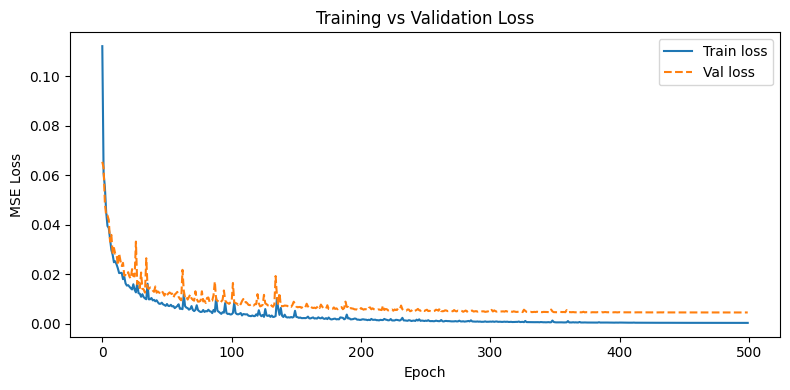

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout(); plt.savefig('training_loss.png', dpi=120); plt.show()

---
## Step 6 — Evaluate on Test Rollouts 💻☁️

A low validation loss means the model predicts expert actions accurately on unseen data — but that's not the same as the robot actually being able to run. When deployed, small prediction errors **compound** over time: the robot ends up in states it never saw during training, which leads to worse predictions, which leads to worse states, and so on.

The true test is to **roll the learned policy out in the environment** and measure the total reward it earns. We compare this against the expert over `NUM_EVAL_TRAJ` fresh episodes (the **test set**).

In [11]:
NUM_EVAL_TRAJ = 10
model = model.cpu().eval()

#hi jake can u see thiss

expert_returns  = []
learned_returns = []

rng = np.random.default_rng(0)
for _ in tqdm(range(NUM_EVAL_TRAJ), desc='Evaluating'):
    seed = int(rng.integers(0, 2**31))

    # ── expert rollout ───────────────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    for _ in range(MAX_TIMESTEPS):
        action, _ = policy.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        if done or truncated: break
    env.close()
    expert_returns.append(ep_reward)

    # ── learned policy rollout ───────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    with torch.no_grad():
        for _ in range(MAX_TIMESTEPS):
            obs_t  = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action = model(obs_t).squeeze(0).numpy()
            obs, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            if done or truncated: break
    env.close()
    learned_returns.append(ep_reward)

expert_returns  = np.array(expert_returns)
learned_returns = np.array(learned_returns)

print(f'Expert  avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'Learned avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
reward_gap = (expert_returns.mean() - learned_returns.mean()) / abs(expert_returns.mean())
print(f'Normalised reward gap: {reward_gap:.1%}')

Evaluating: 100%|██████████| 10/10 [00:04<00:00,  2.03it/s]

Expert  avg return: 3030.9 +/- 45.4
Learned avg return: 2025.6 +/- 1332.2
Normalised reward gap: 33.2%


/tmp/ipykernel_747/3202646983.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([expert_returns, learned_returns],
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


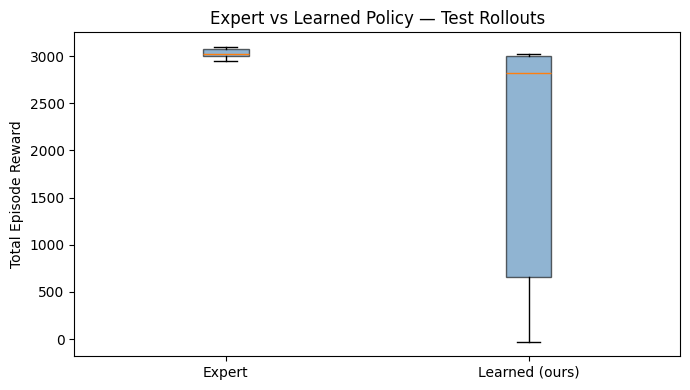

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([expert_returns, learned_returns],
           labels=['Expert', 'Learned (ours)'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Total Episode Reward'); ax.set_title('Expert vs Learned Policy — Test Rollouts')
plt.tight_layout(); plt.savefig('eval_rewards.png', dpi=120); plt.show()

---
# Part 2 — Fine-Tuning the IL Policy with RL (PPO)

Behavior Cloning got our policy running, but it can only ever be as good as the expert
demonstrations it copied — and it never gets feedback on its own mistakes.

Now we hand our IL policy (`model`) over to **PPO (Proximal Policy Optimization)**, an RL
algorithm that improves the policy using **trial and error against the actual reward
signal**, instead of just imitating the expert. Same environment (`HalfCheetah-v5`),
same trained network to start from — but now it gets to keep practicing and improving
past what imitation alone could reach.

The loop (same 4 steps every RL algorithm uses):
```
1. COLLECT  — run the current policy in the environment; store (obs, action, reward, done)
2. ESTIMATE — figure out which actions were better than expected (GAE / advantages)
3. UPDATE   — nudge the policy toward the good actions, away from the bad ones
4. REPEAT
```

> ⚠️ If you're on Colab, make sure you're still on a **T4 GPU** runtime (Runtime → Change
> runtime type). Expected training time: ~15 min GPU / ~30-40 min CPU.

### Step A — A few extra imports

Everything else we need (`torch`, `nn`, `optim`, `gym`, `np`, `tqdm`) is already imported
above. The one new thing PPO needs is `Normal` — a Gaussian (bell-curve) distribution,
used to add exploration noise around the actor's predicted action.

In [13]:
from torch.distributions import Normal

print('Ready for RL fine-tuning.')


Ready for RL fine-tuning.


### Step B — PPO Hyperparameters

Same knobs as a from-scratch PPO run. Since we're *fine-tuning* an already-decent
policy rather than starting from random, you could get away with fewer total steps
(try lowering `TOTAL_STEPS` once you've confirmed everything runs) — but we'll leave
the full budget in by default so you get the clearest possible improvement curve.

In [14]:
# ── Rollout collection ───────────────────────────────────────────────────────
NUM_ENVS      = 4 #basicially like how many are we running at a time
ROLLOUT_STEPS = 2048
TOTAL_STEPS   = 2_000_000

# ── PPO update ───────────────────────────────────────────────────────────────
EPOCHS_PER_ROLLOUT = 10
MINIBATCH_SIZE     = 256
CLIP_EPS           = 0.2
VALUE_LOSS_COEF    = 0.5
ENTROPY_COEF       = 0.0
MAX_GRAD_NORM      = 0.5

# ── Return estimation ────────────────────────────────────────────────────────
GAMMA      = 0.99
GAE_LAMBDA = 0.95

# ── Optimizer ────────────────────────────────────────────────────────────────
LR        = 3e-4
ANNEAL_LR = True

# ── Logging ──────────────────────────────────────────────────────────────────
LOG_INTERVAL  = 5
EVAL_INTERVAL = 20
EVAL_EPISODES = 5

total_rollouts = TOTAL_STEPS // (ROLLOUT_STEPS * NUM_ENVS)
print(f'Total rollouts: {total_rollouts}  ({TOTAL_STEPS/1e6:.1f}M env steps)')
print(f'Data per rollout: {ROLLOUT_STEPS * NUM_ENVS:,} steps')


Total rollouts: 244  (2.0M env steps)
Data per rollout: 8,192 steps


### Step C — The Bridge: turning the IL model into an Actor-Critic

This is the key piece. PPO needs two things your IL `model` doesn't have on its own:
a **critic** (to judge how good a situation is) and a bit of **exploration noise**
around its actions.

So instead of building a new network from scratch, we build one that:
- **Reuses the IL model's trained trunk** (the 3 hidden layers) — already knows how to
  read cheetah observations
- **Reuses the IL model's trained final layer** (`actor_mean`) — already knows how to
  turn that understanding into a reasonable action
- **Bolts on a brand-new critic head** — freshly initialized, since IL never needed one
- **Starts exploration noise smaller than usual** — we don't need to explore as wildly
  as a random policy would, since we're not starting from scratch

In [15]:
class BridgedActorCritic(nn.Module):
    """
    Actor-Critic for PPO that starts from an already-trained IL policy.
    The actor (trunk + action head) is copied straight from `il_model`, so it
    starts out already running reasonably well. Only the critic head is new.
    """
    def __init__(self, il_model, obs_dim, act_dim, hidden=256):
        super().__init__()
        # il_model.net is: Linear, LayerNorm, GELU  (x3)  ->  Linear
        # Split it into "everything but the last Linear" (the trunk) and
        # "the last Linear" (the action head) so we can attach a critic
        # to the same trunk features.

         #trunk is the brain, both actor and criter look at this to gain
            #understanding of situation, its like centrall place to

        layers = list(il_model.net.children())
        self.trunk = nn.Sequential(*layers[:-1])   # reused, already trained
        self.actor_mean = layers[-1]               # reused, already trained
        #takes all the features and predicts best guess

        # NEW: critic head. IL never had one, so this starts from scratch.
        self.critic = nn.Linear(hidden, 1)
            #predicts how much future reward it'll get from the position
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

        # NEW: exploration noise. Initialized smaller (-0.5) than a from-scratch
        # PPO run (which starts at 0) because our actor already runs decently —
        # we want it to explore gently around a good policy, not wildly like a
        # random one.
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)
             #deals with randomness/noise we add on to actor's guess

    def forward(self, obs):
        features = self.trunk(obs)
        return self.actor_mean(features), self.critic(features).squeeze(-1)

    def get_distribution(self, obs):
        mean, _ = self.forward(obs)
        std = self.log_std.exp().expand_as(mean)
        return Normal(mean, std)

    def act(self, obs):
       #used while collecting data, samples noisy action and returns critics opinion
        dist = self.get_distribution(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        _, value = self.forward(obs)
        return action, log_prob, value

    def evaluate(self, obs, action):
       #used during training. when it has a action, it compares the old and new policy
      #sees how likely it was ot pick an action and how good it is??
        dist = self.get_distribution(obs)
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        _, value = self.forward(obs)
        return log_prob, entropy, value


# Sanity check: bridged policy should produce the SAME action as the plain IL
# model for the same input, since the actor weights are literally copied over.
# (The critic output is new/random, so ignore that part.)
test_bridge = BridgedActorCritic(model, OBS_DIM, ACT_DIM, HIDDEN_SIZE).to(DEVICE)
test_obs = torch.zeros(1, OBS_DIM, device=DEVICE)

model_action = model(test_obs)
bridged_mean, _ = test_bridge(test_obs)

print('IL model action:      ', model_action.detach().cpu().numpy())
print('Bridged actor mean:    ', bridged_mean.detach().cpu().numpy())
print('Match:', torch.allclose(model_action, bridged_mean, atol=1e-5))
del test_bridge


IL model action:       [[ 0.92640996 -0.9616532   0.8978908  -0.9498383  -0.9022272  -0.90320617]]
Bridged actor mean:     [[ 0.92640996 -0.9616532   0.8978908  -0.9498383  -0.9022272  -0.90320617]]
Match: True


### Step D — Rollout Buffer, Vectorized Environments, Evaluation Helper

These three pieces don't care what's inside the policy — they just need something
with `.act(obs)` and `.evaluate(obs, action)` and `.forward(obs)` methods, which our
`BridgedActorCritic` provides. Copied over unchanged from the RL notebook.

In [16]:
class RolloutBuffer:
    def __init__(self, steps, num_envs, obs_dim, act_dim, device):
        self.T, self.N = steps, num_envs
        self.device = device
        self.obs       = torch.zeros((steps, num_envs, obs_dim), device=device)
        self.actions   = torch.zeros((steps, num_envs, act_dim), device=device)
        self.rewards   = torch.zeros((steps, num_envs), device=device)
        self.dones     = torch.zeros((steps, num_envs), device=device)
        self.log_probs = torch.zeros((steps, num_envs), device=device)
        self.values    = torch.zeros((steps, num_envs), device=device)
        self.ptr = 0

    def store(self, obs, action, reward, done, log_prob, value):
        self.obs[self.ptr]       = obs
        self.actions[self.ptr]   = action
        self.rewards[self.ptr]   = reward
        self.dones[self.ptr]     = done
        self.log_probs[self.ptr] = log_prob
        self.values[self.ptr]    = value
        self.ptr += 1

    def compute_gae(self, next_value, next_done):
        #basicially sees if the action was good
        #looks to the future to calculae this
        advantages = torch.zeros_like(self.rewards)
        last_adv = 0.0
        for t in reversed(range(self.T)):
            if t == self.T - 1:
                nv = next_value
                nd = next_done
            else:
                nv = self.values[t + 1]
                nd = self.dones[t + 1]
            delta = self.rewards[t] + GAMMA * nv * (1 - nd) - self.values[t]
            last_adv = delta + GAMMA * GAE_LAMBDA * (1 - nd) * last_adv
            advantages[t] = last_adv
        returns = advantages + self.values
          #above is what actually happened, learn to guess this next tme
        return advantages, returns

    def get_minibatches(self, advantages, returns):
        obs_flat = self.obs.view(-1, self.obs.shape[-1])
        act_flat = self.actions.view(-1, self.actions.shape[-1])
        lp_flat  = self.log_probs.view(-1)
        val_flat = self.values.view(-1)
        adv_flat = advantages.view(-1)
        ret_flat = returns.view(-1)

        adv_flat = (adv_flat - adv_flat.mean()) / (adv_flat.std() + 1e-8)

        idx = torch.randperm(obs_flat.shape[0], device=self.device)
        for start in range(0, len(idx), MINIBATCH_SIZE):
            b = idx[start:start + MINIBATCH_SIZE]
            yield obs_flat[b], act_flat[b], lp_flat[b], val_flat[b], adv_flat[b], ret_flat[b]

    def reset(self):
        self.ptr = 0


class VecEnv:
   #this method is just running the 4 cheetahs side by side and if one
  #messes up, it auto resets that one cheetah and keeps the others going
    def __init__(self, env_name, num_envs, seed=0):
        self.envs = [gym.make(env_name) for _ in range(num_envs)]
        self.num_envs = num_envs
        for i, e in enumerate(self.envs):
            e.reset(seed=seed + i)

    def reset(self):
    #reset all envs and return a (num_envs, obs_dim) float32 numpy array
        obs_list = [e.reset()[0] for e in self.envs]
        return __import__('numpy').array(obs_list, dtype='float32')

    def step(self, actions):
        obs_list, reward_list, done_list = [], [], []
        for e, a in zip(self.envs, actions):
            obs, reward, terminated, truncated, info = e.step(a)
            done = terminated or truncated
            if done:
                obs, _ = e.reset()
            obs_list.append(obs)
            reward_list.append(reward)
            done_list.append(done)
        return (np.array(obs_list, dtype=np.float32),
                np.array(reward_list, dtype=np.float32),
                np.array(done_list, dtype=np.float32))

    def close(self):
        for e in self.envs:
            e.close()


def evaluate_policy(policy, env_name, num_episodes=5, max_steps=1000, seed=999):
    """Run the deterministic policy (mean action, no exploration noise) and
    return (mean_return, std_return) over several episodes."""
    #looks at how good the policy is without the random noise messing with score
    #we take the mean to be like no randomness
    policy.eval()
    returns = []
    for ep in range(num_episodes):
        env = gym.make(env_name)
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        with torch.no_grad():
            for _ in range(max_steps):
                obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                mean, _ = policy(obs_t)
                action = mean.squeeze(0).cpu().numpy()
                obs, reward, done, truncated, _ = env.step(action)
                ep_ret += reward
                if done or truncated:
                    break
        env.close()
        returns.append(ep_ret)
    policy.train()
    return np.mean(returns), np.std(returns)

print('Buffer, VecEnv, evaluate_policy defined.')


Buffer, VecEnv, evaluate_policy defined.


### Step E — The PPO Loss

Two losses added together: a **policy loss** (push the actor toward actions that
worked out better than expected, clipped so it can't overreact to one batch) and a
**value loss** (train the critic to better predict how good a state really was).

In [17]:
def ppo_update(policy, optimizer, buffer, advantages, returns):
    pl_log, vl_log, ent_log = [], [], []

    for _ in range(EPOCHS_PER_ROLLOUT):
        for obs_b, act_b, lp_old, val_old, adv_b, ret_b in \
                buffer.get_minibatches(advantages, returns):

            lp_new, ent, val_new = policy.evaluate(obs_b, act_b)

            # ── Policy loss (clipped surrogate) ───────────────────────────
            ratio = torch.exp(lp_new - lp_old)
            pg_loss1 = -adv_b * ratio
            pg_loss2 = -adv_b * ratio.clamp(1 - CLIP_EPS, 1 + CLIP_EPS)
            policy_loss = torch.max(pg_loss1, pg_loss2).mean()
             #if action is good, we wanna increase its ratio
              #if action is bad, we wanna decrease it (duh)
              # (we take the MAX because both terms are negated for gradient ascent)

            # ── Value loss (also clipped, for stability) ──────────────────
              #helps critic be a better predictor
            val_clipped = val_old + (val_new - val_old).clamp(-CLIP_EPS, CLIP_EPS)
            value_loss = 0.5 * torch.max((val_new - ret_b) ** 2,
                                          (val_clipped - ret_b) ** 2).mean()

            loss = policy_loss + VALUE_LOSS_COEF * value_loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            pl_log.append(policy_loss.item())
            vl_log.append(value_loss.item())
            ent_log.append(ent.mean().item())

    return np.mean(pl_log), np.mean(vl_log), np.mean(ent_log)

print('ppo_update() defined.')


ppo_update() defined.


### Step F — Fine-Tune! 🏋️

Same collect → estimate → update loop as before, except now `policy` starts life
already knowing how to run (from the IL model) instead of starting from random
noise. Watch the eval return — it should start noticeably higher than a
from-scratch PPO run would, since it's not starting from zero.

In [18]:
torch.manual_seed(42)
np.random.seed(42)

# The IL baseline score, straight from Step 6's evaluation above — this is our
# "before RL fine-tuning" reference point.
IL_BASELINE_MEAN = float(learned_returns.mean())
IL_BASELINE_STD  = float(learned_returns.std())
print(f'IL baseline (pre-RL) eval return: {IL_BASELINE_MEAN:.1f} +/- {IL_BASELINE_STD:.1f}')

policy    = BridgedActorCritic(model, OBS_DIM, ACT_DIM, HIDDEN_SIZE).to(DEVICE)
optimizer = optim.Adam(policy.parameters(), lr=LR, eps=1e-5)
buffer    = RolloutBuffer(ROLLOUT_STEPS, NUM_ENVS, OBS_DIM, ACT_DIM, DEVICE)
vec_env   = VecEnv(ENV_NAME, NUM_ENVS, seed=42)

obs  = torch.tensor(vec_env.reset(), dtype=torch.float32, device=DEVICE)
done = torch.zeros(NUM_ENVS, device=DEVICE)

episode_returns_rl = []
eval_steps_rl      = []
eval_means_rl      = []
eval_stds_rl       = []
policy_losses_rl   = []
value_losses_rl    = []
steps_done         = 0
current_ep_ret      = torch.zeros(NUM_ENVS, device=DEVICE)

pbar = tqdm(range(total_rollouts), desc='PPO fine-tune')
for rollout_idx in pbar:

    if ANNEAL_LR:
        frac = 1.0 - rollout_idx / total_rollouts
        for g in optimizer.param_groups:
            g['lr'] = LR * frac

    # ── Collect rollout ────────────────────────────────────────────────────
    buffer.reset()
    policy.eval()
    rollout_ep_returns = []

    with torch.no_grad():
        for step in range(ROLLOUT_STEPS):
            action, log_prob, value = policy.act(obs)
            action_np = action.cpu().numpy()
            next_obs_np, reward_np, done_np = vec_env.step(action_np)

            reward    = torch.tensor(reward_np, dtype=torch.float32, device=DEVICE)
            next_obs  = torch.tensor(next_obs_np, dtype=torch.float32, device=DEVICE)
            next_done = torch.tensor(done_np, dtype=torch.float32, device=DEVICE)

            buffer.store(obs, action, reward, done, log_prob, value)

            current_ep_ret += reward
            for i, d in enumerate(done_np):
                if d:
                    rollout_ep_returns.append(current_ep_ret[i].item())
                    current_ep_ret[i] = 0.0

            obs  = next_obs
            done = next_done

        _, _, next_value = policy.act(obs)

    advantages, returns = buffer.compute_gae(next_value, done)
    steps_done += ROLLOUT_STEPS * NUM_ENVS

    # ── PPO update ─────────────────────────────────────────────────────────
    policy.train()
    pl, vl, ent = ppo_update(policy, optimizer, buffer, advantages, returns)
    policy_losses_rl.append(pl)
    value_losses_rl.append(vl)

    if rollout_ep_returns:
        episode_returns_rl.append(np.mean(rollout_ep_returns))

    if (rollout_idx + 1) % LOG_INTERVAL == 0:
        avg = np.mean(episode_returns_rl[-20:]) if episode_returns_rl else float('nan')
        pbar.set_postfix({'steps': f'{steps_done/1e6:.2f}M', 'ret': f'{avg:.0f}',
                          'pl': f'{pl:.4f}', 'vl': f'{vl:.2f}'})

    if (rollout_idx + 1) % EVAL_INTERVAL == 0:
        m, s = evaluate_policy(policy, ENV_NAME, num_episodes=EVAL_EPISODES)
        eval_means_rl.append(m); eval_stds_rl.append(s); eval_steps_rl.append(steps_done)
        print(f'\n[{steps_done/1e6:.2f}M steps] eval: {m:.1f} +/- {s:.1f}')

vec_env.close()
print('\nFine-tuning complete!')
torch.save(policy.state_dict(), 'ppo_finetuned_policy.pt')
print('Saved ppo_finetuned_policy.pt')


IL baseline (pre-RL) eval return: 2025.6 +/- 1332.2


PPO fine-tune:   8%|▊         | 20/244 [02:14<28:02,  7.51s/it, steps=0.16M, ret=274, pl=-0.0371, vl=97.25]


[0.16M steps] eval: 2350.2 +/- 90.8


PPO fine-tune:  16%|█▋        | 40/244 [04:27<25:29,  7.50s/it, steps=0.33M, ret=1256, pl=-0.0406, vl=293.24]


[0.33M steps] eval: 2799.5 +/- 278.6


...


[1.80M steps] eval: 2853.9 +/- 2149.3


PPO fine-tune:  98%|█████████▊| 240/244 [26:28<00:30,  7.50s/it, steps=1.97M, ret=1879, pl=-0.0057, vl=948.16]


[1.97M steps] eval: 3051.1 +/- 1487.1


PPO fine-tune: 100%|██████████| 244/244 [26:54<00:00,  6.62s/it, steps=1.97M, ret=1879, pl=-0.0057, vl=948.16]


Fine-tuning complete!
Saved ppo_finetuned_policy.pt


### Step G — Training Curves (IL baseline vs RL fine-tuned)

Same curves as the RL notebook, plus the IL baseline drawn in as a flat reference
line on the eval-return plot — so you can see exactly how much RL improved on top
of imitation learning alone.

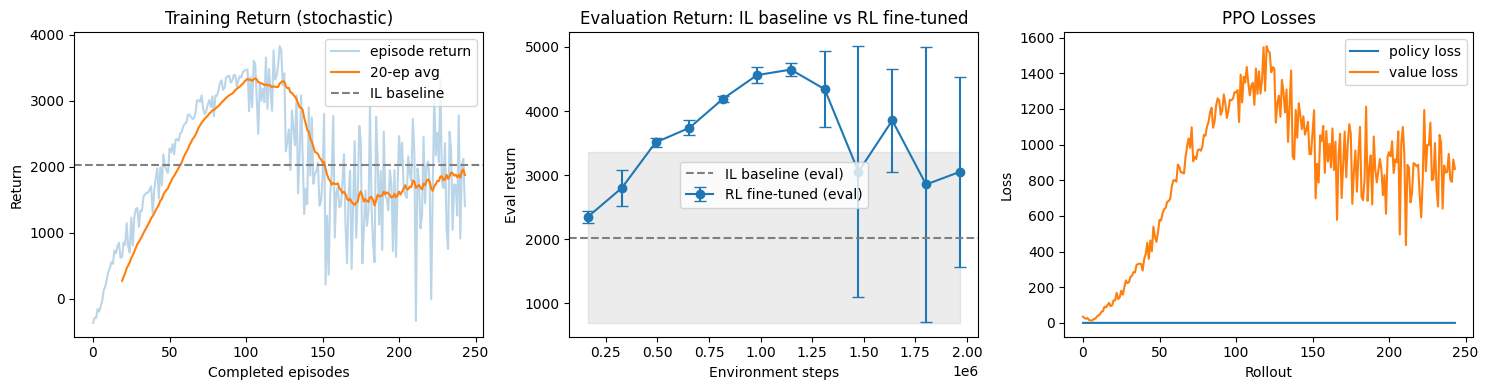

IL baseline eval return:       2025.6 +/- 1332.2
RL fine-tuned final eval:      3051.1 +/- 1487.1
Improvement from fine-tuning:  +1025.5


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_returns_rl, alpha=0.3, label='episode return')
W = 20
if len(episode_returns_rl) >= W:
    smooth = np.convolve(episode_returns_rl, np.ones(W)/W, mode='valid')
    axes[0].plot(range(W-1, len(episode_returns_rl)), smooth, label=f'{W}-ep avg')
axes[0].axhline(IL_BASELINE_MEAN, color='gray', linestyle='--', label='IL baseline')
axes[0].set_xlabel('Completed episodes'); axes[0].set_ylabel('Return')
axes[0].set_title('Training Return (stochastic)'); axes[0].legend()

axes[1].errorbar(eval_steps_rl, eval_means_rl, yerr=eval_stds_rl,
                  fmt='o-', capsize=4, label='RL fine-tuned (eval)')
axes[1].axhline(IL_BASELINE_MEAN, color='gray', linestyle='--', label='IL baseline (eval)')
axes[1].fill_between(eval_steps_rl,
                      IL_BASELINE_MEAN - IL_BASELINE_STD,
                      IL_BASELINE_MEAN + IL_BASELINE_STD,
                      color='gray', alpha=0.15)
axes[1].set_xlabel('Environment steps'); axes[1].set_ylabel('Eval return')
axes[1].set_title('Evaluation Return: IL baseline vs RL fine-tuned'); axes[1].legend()

axes[2].plot(policy_losses_rl, label='policy loss')
axes[2].plot(value_losses_rl, label='value loss')
axes[2].set_xlabel('Rollout'); axes[2].set_ylabel('Loss')
axes[2].set_title('PPO Losses'); axes[2].legend()

plt.tight_layout()
plt.savefig('il_plus_rl_comparison.png', dpi=120)
plt.show()

print(f'IL baseline eval return:       {IL_BASELINE_MEAN:.1f} +/- {IL_BASELINE_STD:.1f}')
print(f'RL fine-tuned final eval:      {eval_means_rl[-1]:.1f} +/- {eval_stds_rl[-1]:.1f}')
improvement = eval_means_rl[-1] - IL_BASELINE_MEAN
print(f'Improvement from fine-tuning:  {improvement:+.1f}')

#im kinda confused about the graphs a litt.e isnt is sus that the ppo loss went up and then back down?? like i feel we peaked and then we kept going and it started going bad
